In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import os
import missingno as msno

from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score,roc_curve,classification_report,confusion_matrix,accuracy_score,cohen_kappa_score,RocCurveDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv('aug_train.csv')

In [4]:
df.shape

(19158, 14)

In [5]:
df.dtypes.value_counts()

object     10
int64       2
float64     2
Name: count, dtype: int64

In [6]:
df.nunique()

enrollee_id               19158
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   22
company_size                  8
company_type                  6
last_new_job                  6
training_hours              241
target                        2
dtype: int64

In [7]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [8]:
df.tail()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0
19157,23834,city_67,0.855,NaN,No relevent experience,no_enrollment,Primary School,NaN,2,NaN,NaN,1,127,0.0


In [9]:
df.sample(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
10982,14605,city_16,0.910,Male,Has relevent experience,no_enrollment,Masters,STEM,6,5000-9999,Pvt Ltd,1,94,0.0
10790,15167,city_103,0.920,Female,Has relevent experience,no_enrollment,Masters,STEM,6,5000-9999,Pvt Ltd,1,16,0.0
11772,14610,city_90,0.698,Male,Has relevent experience,no_enrollment,Graduate,STEM,9,10/49,Pvt Ltd,1,11,0.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [11]:
df.isna().sum().sort_values(ascending=False)/len(df)*100

company_type              32.049274
company_size              30.994885
gender                    23.530640
major_discipline          14.683161
education_level            2.401086
last_new_job               2.207955
enrolled_university        2.014824
experience                 0.339284
enrollee_id                0.000000
city                       0.000000
relevent_experience        0.000000
city_development_index     0.000000
training_hours             0.000000
target                     0.000000
dtype: float64

In [12]:
df.describe(include='all') #<-- NEW THING 

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
count,19158.000000,19158,19158.000000,14650,19158,18772,18698,16345,19093,13220,13018,18735,19158.000000,19158.000000
unique,NaN,123,NaN,3,2,3,5,6,22,8,6,6,NaN,NaN
top,NaN,city_103,NaN,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1,NaN,NaN
freq,NaN,4355,NaN,13221,13792,13817,11598,14492,3286,3083,9817,8040,NaN,NaN
mean,16875.358179,NaN,0.828848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.366896,0.249348
std,9616.292592,NaN,0.123362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.058462,0.432647
min,1.000000,NaN,0.448000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
25%,8554.250000,NaN,0.740000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000,0.000000
50%,16982.500000,NaN,0.903000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.000000,0.000000
75%,25169.750000,NaN,0.920000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.000000,0.000000


In [13]:
# Too Early to call skew corr and kurt ; must be called later 

In [14]:
# groupby Intution 
''' 
Example 1: Useless Column
pythondf.groupby('gender')['churn'].mean()

# Output:
# Male:   0.27
# Female: 0.28
# Difference: 0.01 (1%)

# Overall churn rate: 0.27
What this tells you:

Whether customer is Male or Female, ~27% churn
Gender provides NO INFORMATION about churn
Model will learn: "gender doesn't matter"

If you encode and include it:
python# After encoding: gender_Male (0 or 1)
# Model learns: coefficient ≈ 0.01 (nearly zero)
# You wasted computation encoding a useless feature

Example 2: Powerful Column
pythondf.groupby('contract_type')['churn'].mean()

# Output:
# Month-to-month: 0.85  (85% churn!)
# One year:       0.15  (15% churn)
# Two year:       0.05  (5% churn)
# Difference: 0.80 (80%!)

# Overall churn rate: 0.35
What this tells you:

Contract type STRONGLY predicts churn
Month-to-month customers churn 17x more than two-year!
This MUST be encoded and included
'''

' \nExample 1: Useless Column\npythondf.groupby(\'gender\')[\'churn\'].mean()\n\n# Output:\n# Male:   0.27\n# Female: 0.28\n# Difference: 0.01 (1%)\n\n# Overall churn rate: 0.27\nWhat this tells you:\n\nWhether customer is Male or Female, ~27% churn\nGender provides NO INFORMATION about churn\nModel will learn: "gender doesn\'t matter"\n\nIf you encode and include it:\npython# After encoding: gender_Male (0 or 1)\n# Model learns: coefficient ≈ 0.01 (nearly zero)\n# You wasted computation encoding a useless feature\n\nExample 2: Powerful Column\npythondf.groupby(\'contract_type\')[\'churn\'].mean()\n\n# Output:\n# Month-to-month: 0.85  (85% churn!)\n# One year:       0.15  (15% churn)\n# Two year:       0.05  (5% churn)\n# Difference: 0.80 (80%!)\n\n# Overall churn rate: 0.35\nWhat this tells you:\n\nContract type STRONGLY predicts churn\nMonth-to-month customers churn 17x more than two-year!\nThis MUST be encoded and included\n'

In [15]:
grp_exp_target = df.groupby('relevent_experience')['target']

In [16]:
for x in df.select_dtypes('object').drop(columns=['city','experience']).columns:
    grouping = df.groupby(x)['target']
    print(f'The mean of the group : {grouping.mean()}\n')
    print(f'The std of the group : {grouping.std()}\n')


The mean of the group : gender
Female    0.263328
Male      0.227819
Other     0.261780
Name: target, dtype: float64

The std of the group : gender
Female    0.440617
Male      0.419441
Other     0.440759
Name: target, dtype: float64

The mean of the group : relevent_experience
Has relevent experience    0.214690
No relevent experience     0.338427
Name: target, dtype: float64

The std of the group : relevent_experience
Has relevent experience    0.410622
No relevent experience     0.473219
Name: target, dtype: float64

The mean of the group : enrolled_university
Full time course    0.380889
Part time course    0.252087
no_enrollment       0.211406
Name: target, dtype: float64

The std of the group : enrolled_university
Full time course    0.485670
Part time course    0.434392
no_enrollment       0.408321
Name: target, dtype: float64

The mean of the group : education_level
Graduate          0.279790
High School       0.195340
Masters           0.214400
Phd               0.140097
Prima

In [17]:
'''
I think the usefull columns are : 

relevent_experience , enrolled_university , education_level ,
 major_discipline , company_size , company_type ,  last_new_job
( everything expect gender ) 

'''

# This means gender doesnt contributes that much to our model

'\nI think the usefull columns are : \n\nrelevent_experience , enrolled_university , education_level ,\n major_discipline , company_size , company_type ,  last_new_job\n( everything expect gender ) \n\n'

In [18]:
# IMPROVEMENT
'''
def analyze_categorical_columns(df, target_col='target', exclude_cols=None):
    """
    Pre-analysis: Check which categorical columns are worth keeping
    """
    if exclude_cols is None:
        exclude_cols = []
    
    categorical_cols = df.select_dtypes('object').columns
    categorical_cols = [col for col in categorical_cols if col not in exclude_cols]
    
    results = []
    
    print("="*70)
    print("CATEGORICAL COLUMN ANALYSIS")
    print("="*70)
    
    for col in categorical_cols:
        print(f"\n📊 Column: {col}")
        print("-" * 70)
        
        # Group by category
        grouped = df.groupby(col)[target_col].agg(['count', 'mean', 'std'])
        print(grouped.sort_values('mean', ascending=False))
        
        # Calculate useful metrics
        overall_mean = df[target_col].mean()
        max_diff = grouped['mean'].max() - grouped['mean'].min()
        mean_std = grouped['mean'].std()
        
        # Decision
        is_useful = max_diff > 0.05  # Categories differ by >5%
        
        print(f"\n📈 Overall target mean: {overall_mean:.3f}")
        print(f"📈 Max difference between categories: {max_diff:.3f}")
        print(f"📈 Variance in category means: {mean_std:.3f}")
        
        if is_useful:
            print(f"✅ VERDICT: USEFUL - Keep this column")
        else:
            print(f"❌ VERDICT: LOW SIGNAL - Consider dropping")
        
        results.append({
            'column': col,
            'num_categories': df[col].nunique(),
            'max_diff': max_diff,
            'is_useful': is_useful
        })
    
    # Summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    summary_df = pd.DataFrame(results).sort_values('max_diff', ascending=False)
    print(summary_df)
    
    print(f"\n✅ Useful columns: {summary_df[summary_df['is_useful']]['column'].tolist()}")
    print(f"❌ Consider dropping: {summary_df[~summary_df['is_useful']]['column'].tolist()}")
    
    return summary_df

# Usage:
results = analyze_categorical_columns(df, target_col='churn', exclude_cols=['city', 'experience'])
```

---

## **What This Improved Version Does:**

1. **Shows WHICH column** you're analyzing
2. **Shows the actual categories** and their counts
3. **Gives a verdict** - keep or drop?
4. **Returns a summary** you can use for decisions
5. **No hardcoded drops** - flexible for any dataset
6. **Sorted by importance** - see best features first

---

## **Example Output:**
```
======================================================================
CATEGORICAL COLUMN ANALYSIS
======================================================================

📊 Column: contract_type
----------------------------------------------------------------------
                    count      mean       std
contract_type                               
Month-to-month        100  0.900000  0.302765
One year               50  0.100000  0.303046
Two year               20  0.050000  0.223607

📈 Overall target mean: 0.350
📈 Max difference between categories: 0.850
📈 Variance in category means: 0.457
✅ VERDICT: USEFUL - Keep this column

📊 Column: gender
----------------------------------------------------------------------
           count      mean       std
gender                              
Male        85   0.352941  0.480384
Female      85   0.347059  0.478746

📈 Overall target mean: 0.350
📈 Max difference between categories: 0.006
📈 Variance in category means: 0.004
❌ VERDICT: LOW SIGNAL - Consider dropping

======================================================================
SUMMARY
======================================================================
          column  num_categories  max_diff  is_useful
0  contract_type               3     0.850       True
1         gender               2     0.006      False

✅ Useful columns: ['contract_type']
❌ Consider dropping: ['gender']
'''

'\ndef analyze_categorical_columns(df, target_col=\'target\', exclude_cols=None):\n    """\n    Pre-analysis: Check which categorical columns are worth keeping\n    """\n    if exclude_cols is None:\n        exclude_cols = []\n\n    categorical_cols = df.select_dtypes(\'object\').columns\n    categorical_cols = [col for col in categorical_cols if col not in exclude_cols]\n\n    results = []\n\n    print("="*70)\n    print("CATEGORICAL COLUMN ANALYSIS")\n    print("="*70)\n\n    for col in categorical_cols:\n        print(f"\n📊 Column: {col}")\n        print("-" * 70)\n\n        # Group by category\n        grouped = df.groupby(col)[target_col].agg([\'count\', \'mean\', \'std\'])\n        print(grouped.sort_values(\'mean\', ascending=False))\n\n        # Calculate useful metrics\n        overall_mean = df[target_col].mean()\n        max_diff = grouped[\'mean\'].max() - grouped[\'mean\'].min()\n        mean_std = grouped[\'mean\'].std()\n\n        # Decision\n        is_useful = max_diff

In [19]:
# Numeric Value Analysis 

In [20]:
numeric_columns = df.select_dtypes(include = ['int','float']).drop(columns=['enrollee_id']).columns

## Skewness


| Value of Skewness ($S$) | Distribution Shape | Direction of "Tail" | Data Concentration | Mean vs. Median |
| :--- | :--- | :--- | :--- | :--- |
| **$S = 0$** | **Symmetric** | No tail; balanced | Evenly around center | $\text{Mean} = \text{Median}$ |
| **$S < 0$** (Negative) | **Left-Skewed** | Long tail to the **Left** | Bunched on the Right | $\text{Mean} < \text{Median}$ |
| **$S > 0$** (Positive) | **Right-Skewed** | Long tail to the **Right** | Bunched on the Left | $\text{Mean} > \text{Median}$ |



| Numeric Range | Strength of Skewness | Typical Interpretation |
| :--- | :--- | :--- |
| **$0$ to $\pm 0.5$** | **Slight / Fairly Symmetric** | Approximately normal; safe for most tests. |
| **$\pm 0.5$ to $\pm 1.0$** | **Moderate** | Moderately skewed; Median is often preferred. |
| **Beyond $\pm 1.0$** | **High / Severe** | Highly skewed; data transformation may be needed. |


# Understanding Kurtosis

Kurtosis measures the "tailedness" of a probability distribution. The formula for **population kurtosis** is defined as the fourth standardized moment:

$$Kurtosis = \frac{\mathbb{E}[(X - \mu)^4]}{\sigma^4}$$

### Summary of Kurtosis Values
| Category | Kurtosis (Absolute) | Excess Kurtosis | Shape | Outlier Frequency |
| :--- | :--- | :--- | :--- | :--- |
| **Mesokurtic** | Exactly 3.0 | 0 | Normal / Bell | Moderate |
| **Leptokurtic** | > 3.0 | Positive (> 0) | Sharp / Skinny | **High (Heavy tails)** |
| **Platykurtic** | < 3.0 | Negative (< 0) | Flat / Broad | **Low (Thin tails)** |




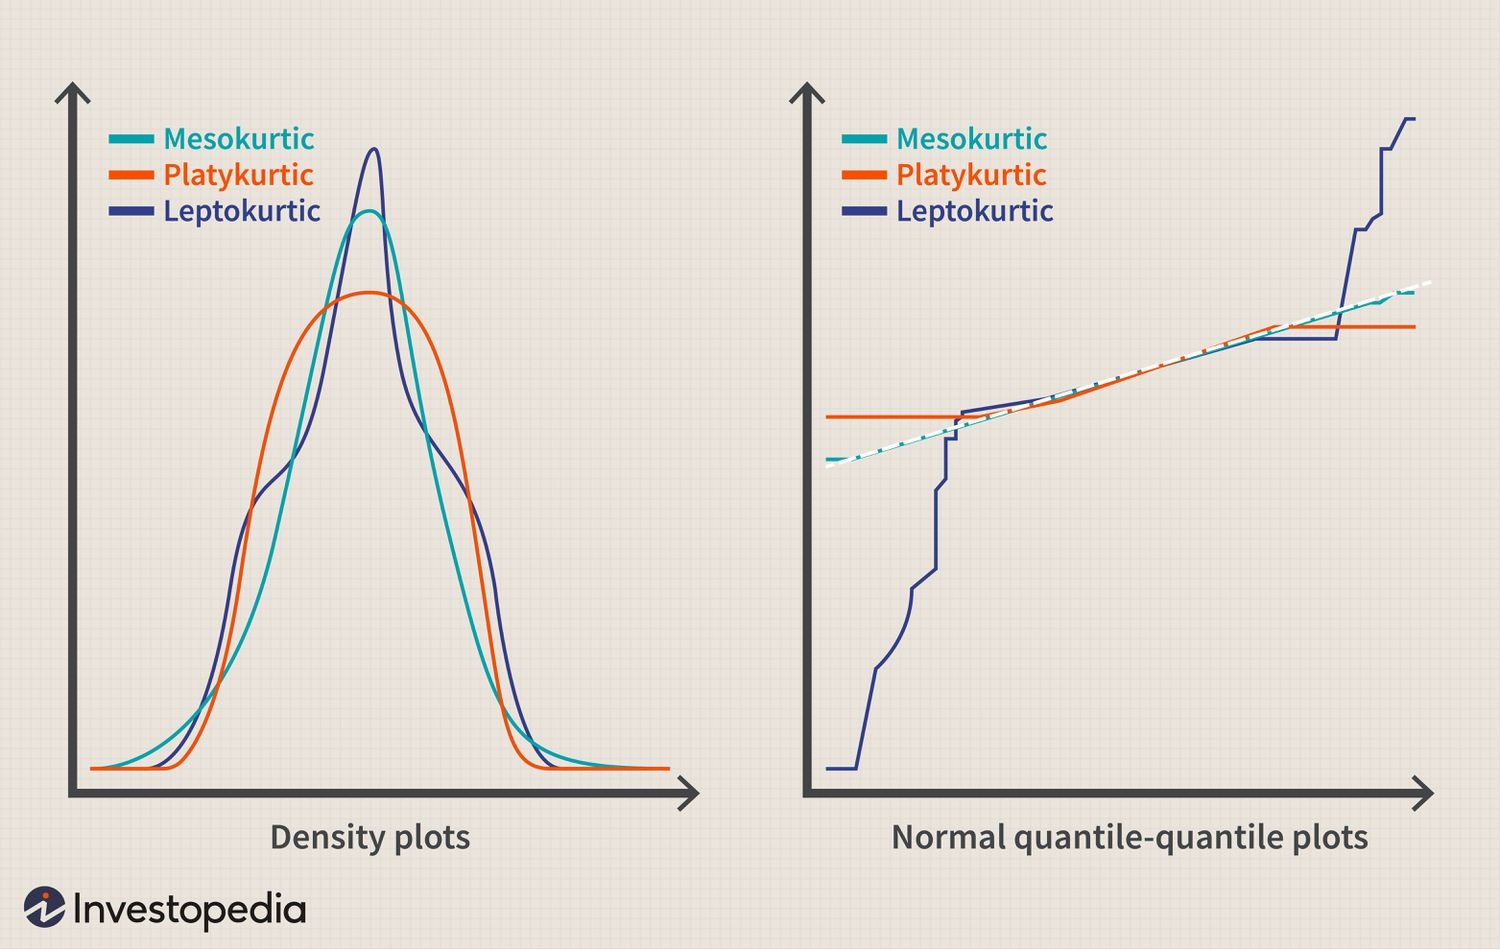

In [21]:
df[numeric_columns].corr(numeric_only=True)['target'] # <-- Corr with the target

city_development_index   -0.341665
training_hours           -0.021577
target                    1.000000
Name: target, dtype: float64

In [22]:
df[numeric_columns].skew(numeric_only=True) # Again there is posisive and negative skewness both need to be handled later

city_development_index   -0.995428
training_hours            1.819237
target                    1.158815
dtype: float64

In [23]:
df[numeric_columns].kurt(numeric_only=True)  # Here we get to know that we have extreme tailedness

city_development_index   -0.538532
training_hours            3.840539
target                   -0.657217
dtype: float64

In [24]:
# Plotting 

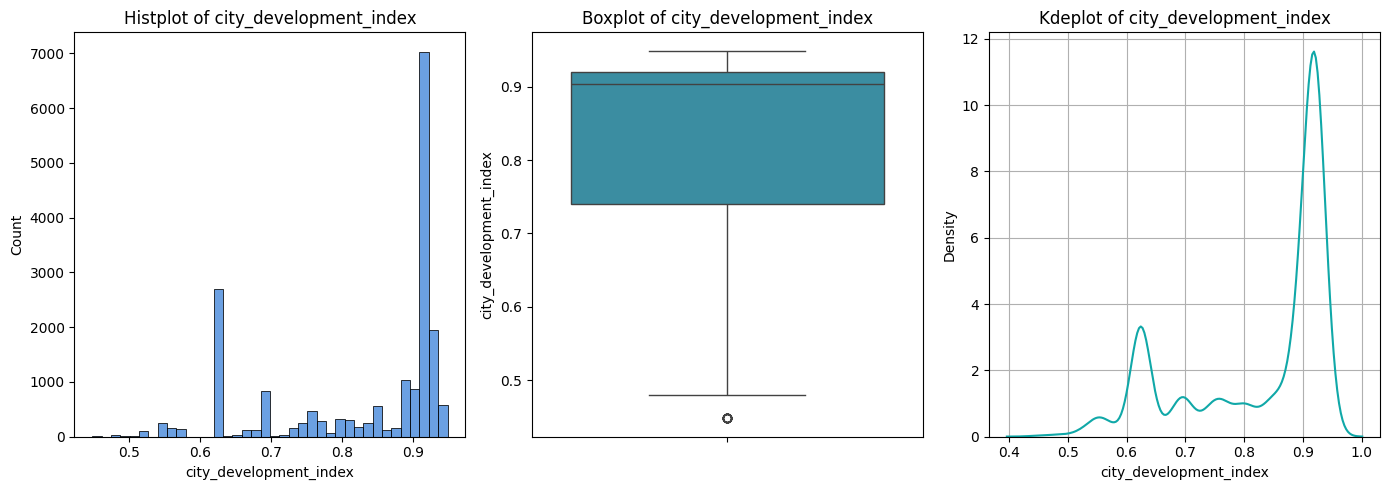

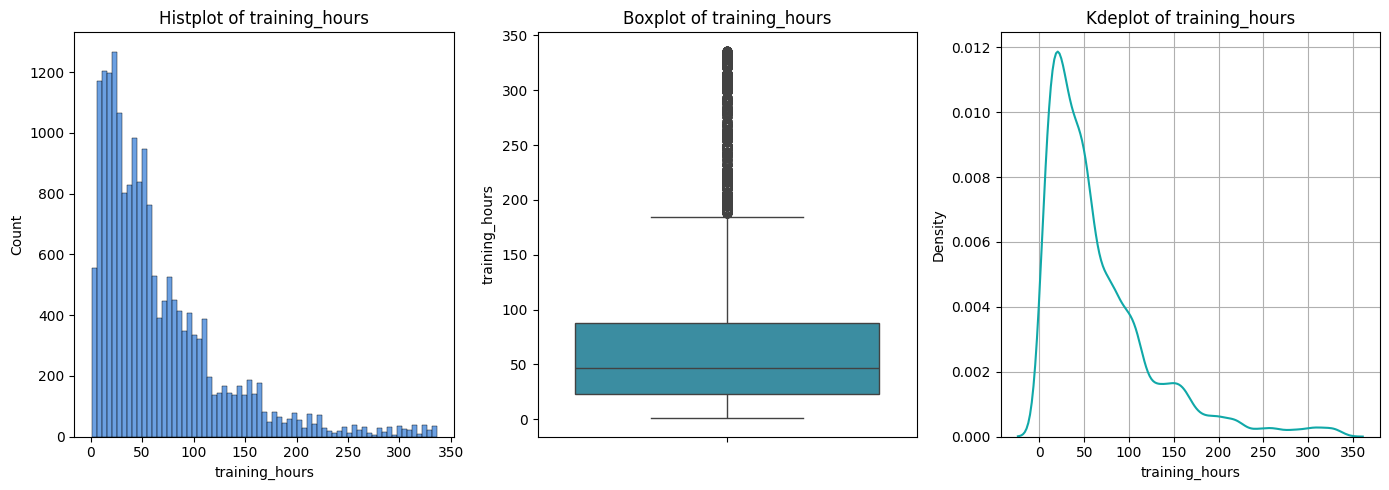

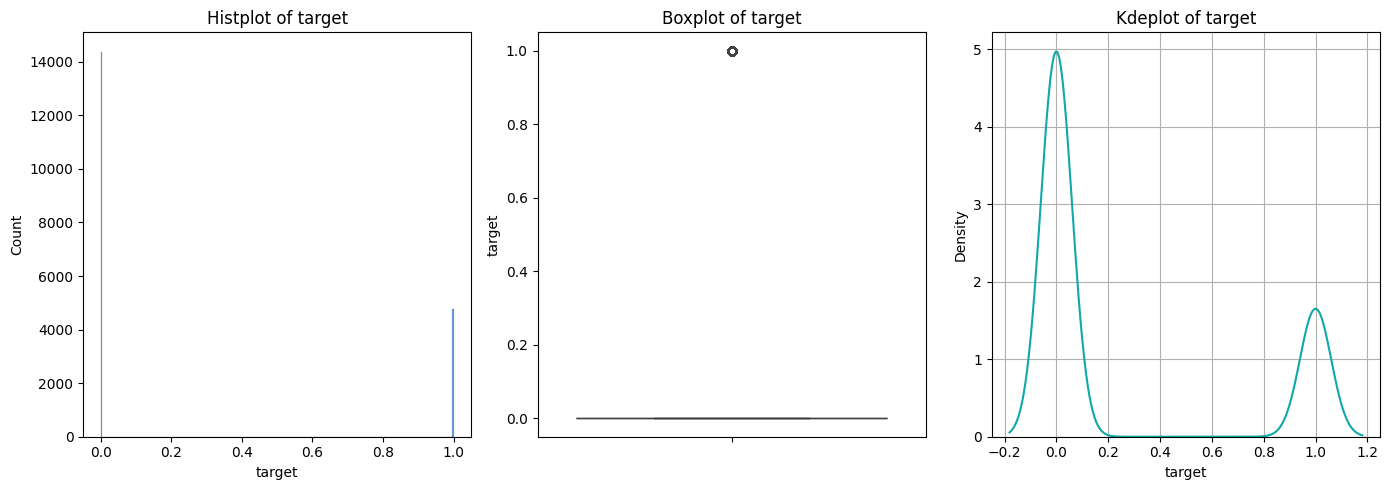

In [25]:
for x in numeric_columns:

    figure , axes = plt.subplots(1,3,figsize=(14,5))

    sns.histplot(
                    data = df,
                    x = x,
                    ax = axes[0],
                    color = "#3A81D9"
    )
    axes[0].set_title(f'Histplot of {x}')

    sns.boxplot(
                    data = df,
                    y = x,
                    ax = axes[1],
                    color = "#2A97B2"
    )
    axes[1].set_title(f'Boxplot of {x}')

    sns.kdeplot(
                    data = df,
                    x = x,
                    ax = axes[2],
                    color = "#10A8A8"
    )
    axes[2].set_title(f'Kdeplot of {x}')

    plt.tight_layout()
    plt.grid()
    plt.show()

In [26]:
# These graphs give more better insights and planning on what to do ahead

In [27]:
# Now moving to visualizing categorical datatypes

In [28]:
categorical_columns = df.select_dtypes(include='object').drop(columns=['gender','city']).columns

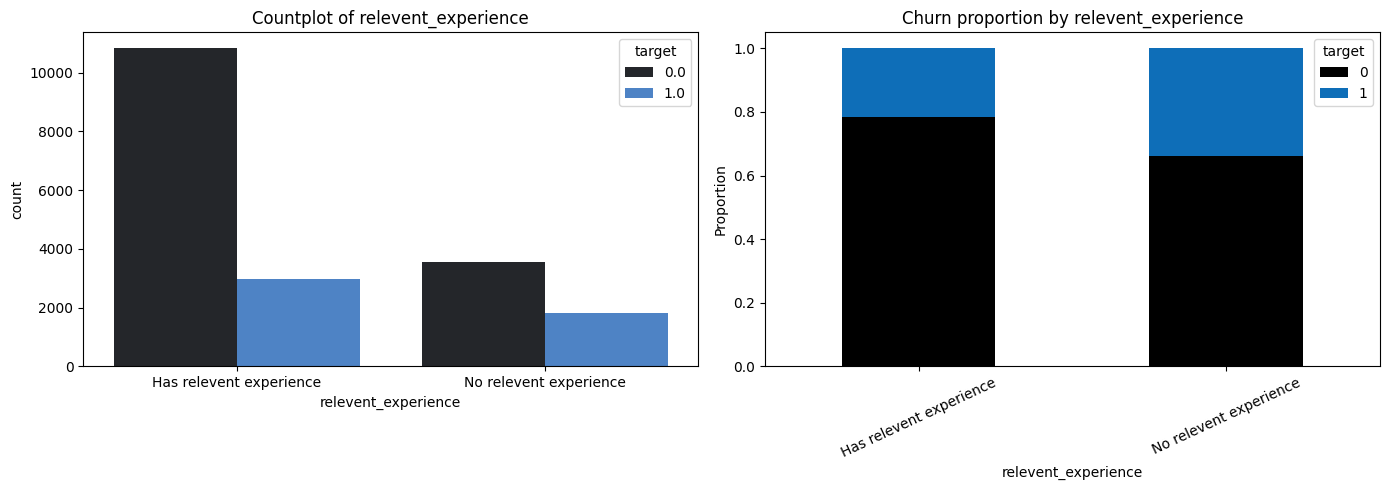

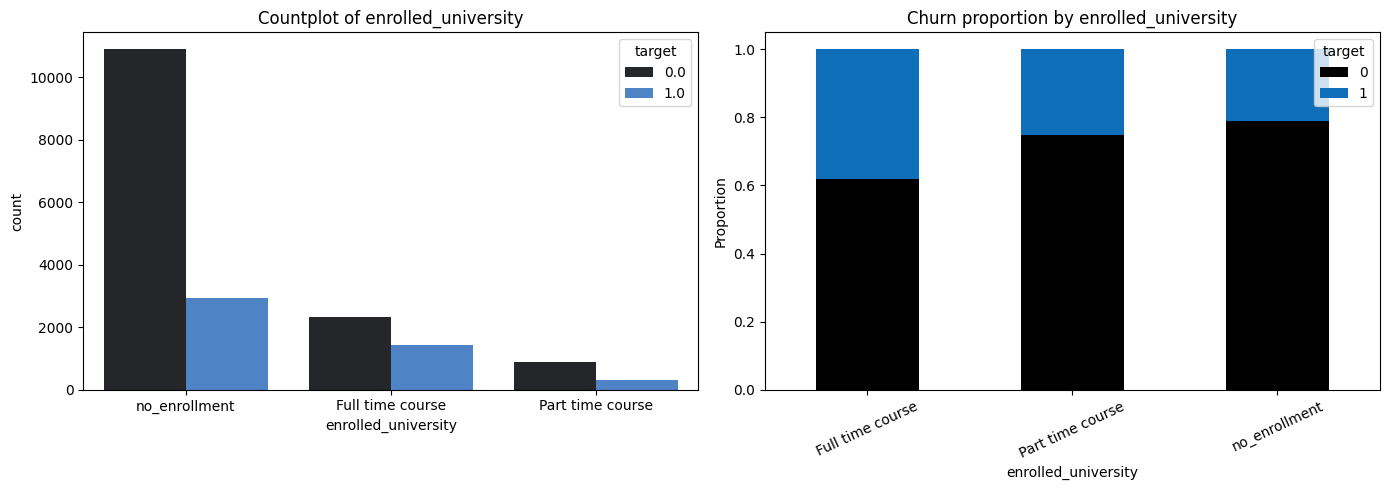

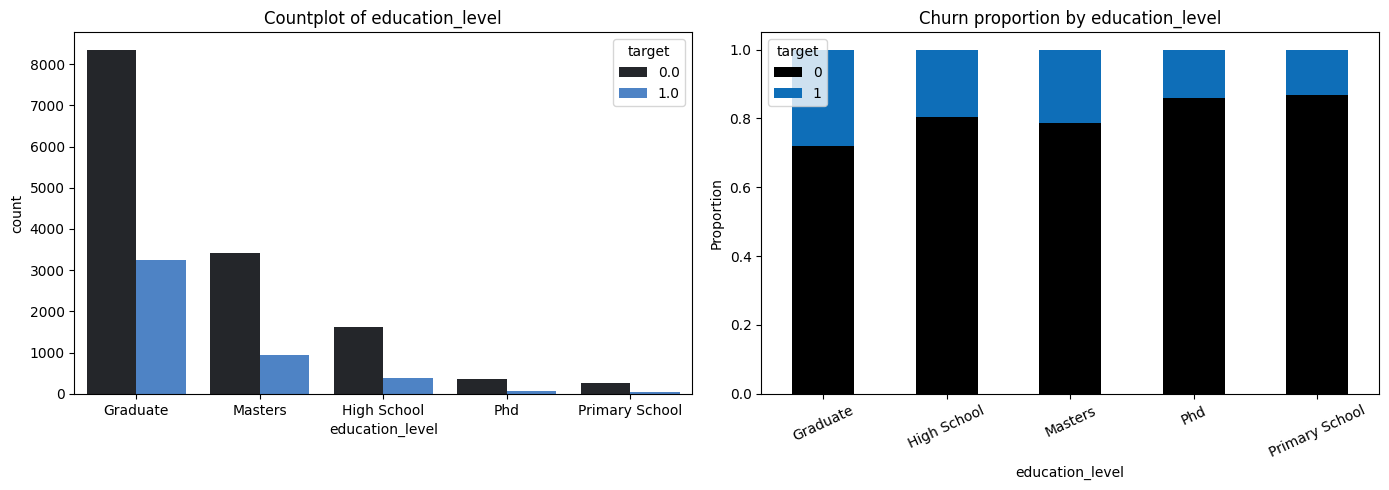

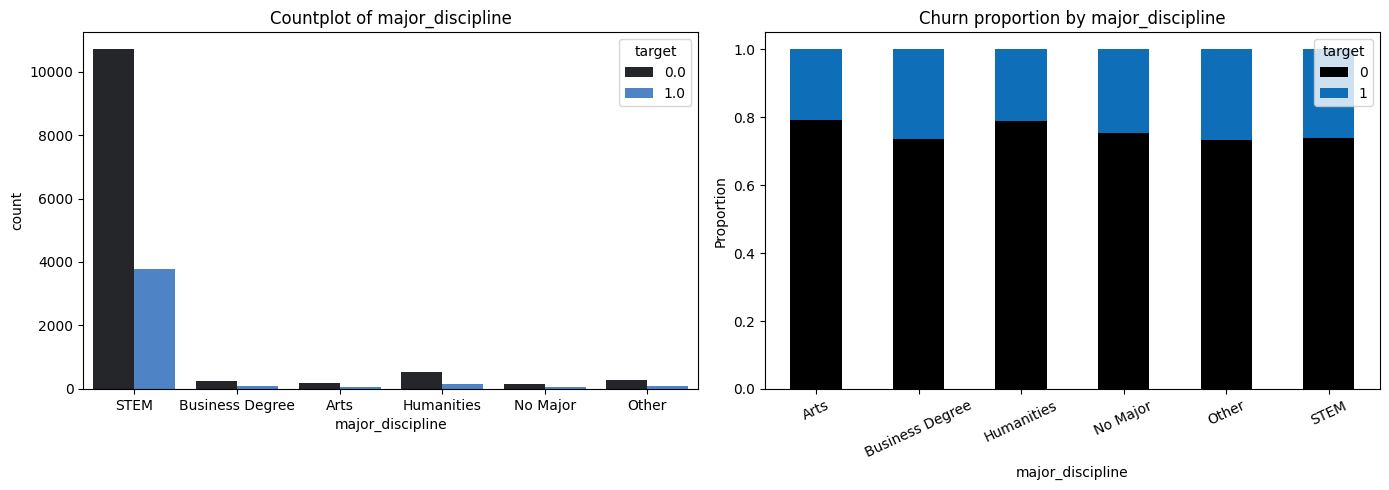

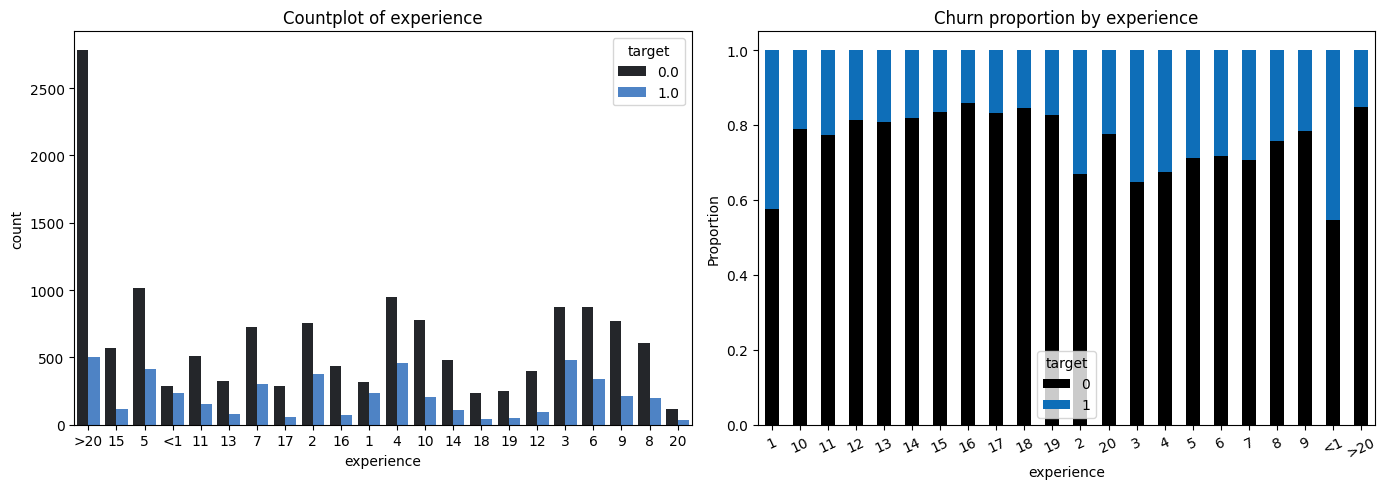

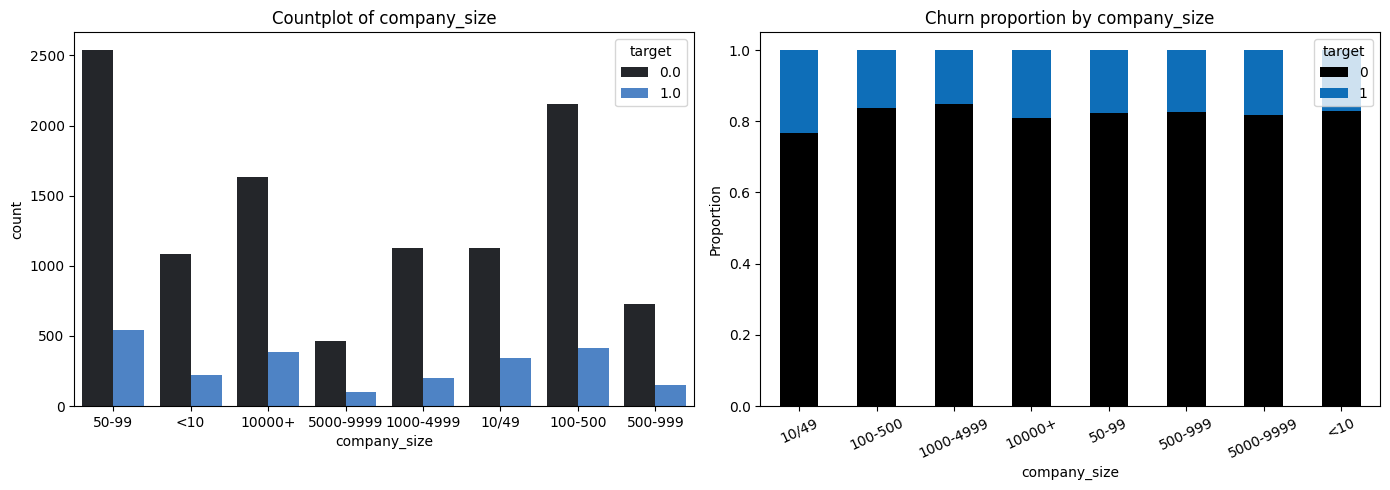

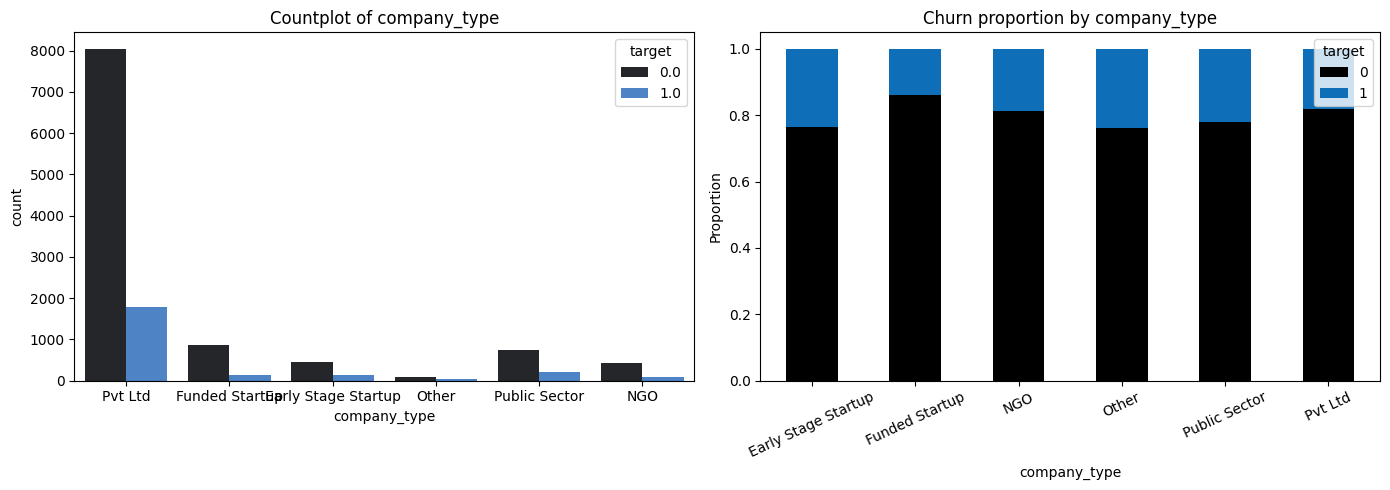

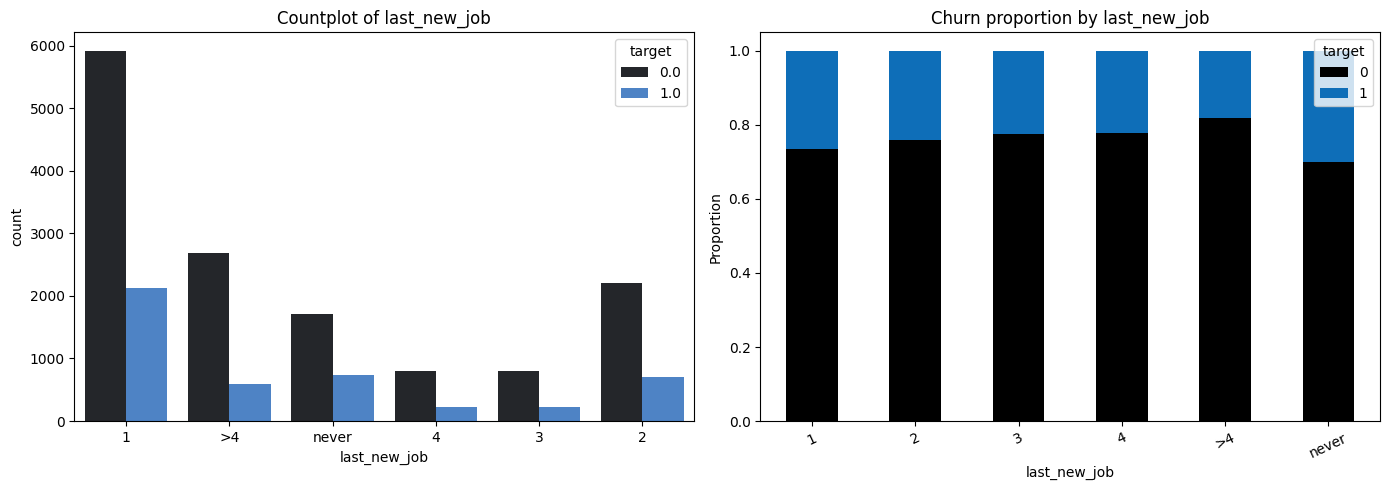

In [29]:
for x in categorical_columns:

    figure , axes = plt.subplots(1,2,figsize=(14,5))

    sns.countplot(
                    data = df,
                    x = x,
                    ax = axes[0],
                    palette='dark:#3A81D9',
                    hue = 'target'
    )
    axes[0].set_title(f'Countplot of {x}')

    # sns.barplot(
    #                 data = df,
    #                 x = x,
    #                 y = 'target',
    #                 hue = x,
    #                 ax = axes[1],
    #                 palette="dark:#0994B6",
    #                 legend=False,
    #                 width = 0.75,
    #                 gap = 0,
    #                 saturation=1.0,
    #                 errorbar=None
    # )
    # axes[1].set_title(f'Barplot of {x}')

    crosstab = pd.crosstab(df[x],df['target'],normalize='index')
    crosstab.plot(
                    kind='bar',
                    stacked = True,
                    color = ['#000000',"#0E6EB8"],
                    ax = axes[1]
        )
    axes[1].set_title(f'Churn proportion by {x}')
    axes[1].set_ylabel('Proportion')
    axes[1].legend(title='target',labels=['0','1'])
    axes[1].tick_params(axis='x', rotation=25)
    
    '''
    sns.violinplot(
                    data = df,
                    y = x,
                    hue = 'target',
                    palette='light:#3A81D9',
                    ax = axes[1]
    )
    axes[1].set_title(f'Violinplot of {x}')
    '''

    plt.tight_layout()
    plt.show()

In [30]:
# From above I found out that we can maybe make groupings for company_type , major_discipline and education level .

In [31]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
10457,22285,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,100-500,Pvt Ltd,>4,11,0.0
13006,19376,city_21,0.624,Male,Has relevent experience,Full time course,Graduate,STEM,8,100-500,Pvt Ltd,1,31,0.0
17550,8370,city_103,0.920,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,Public Sector,1,28,1.0
9135,16380,city_21,0.624,NaN,Has relevent experience,Full time course,Graduate,STEM,<1,<10,NGO,>4,18,1.0
3693,12324,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,11,5000-9999,Pvt Ltd,1,110,0.0


In [32]:
# we will now drop irrelevant columns that are not needed before proceeding further 

In [33]:
df = df.drop(columns=['city','enrollee_id','gender'])

In [34]:
df.sample(5)

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
1624,0.949,Has relevent experience,no_enrollment,Graduate,STEM,>20,<10,Funded Startup,2,35,0.0
2741,0.624,Has relevent experience,Full time course,Graduate,STEM,1,50-99,Pvt Ltd,1,7,1.0
6896,0.920,No relevent experience,no_enrollment,Graduate,Arts,2,1000-4999,Pvt Ltd,2,80,1.0
16172,0.624,Has relevent experience,no_enrollment,Graduate,STEM,10,1000-4999,Pvt Ltd,2,14,0.0
666,0.920,Has relevent experience,no_enrollment,Graduate,STEM,5,50-99,Pvt Ltd,2,25,1.0


In [35]:
# Lets construct a for loop that gives us with nuniquevalues in group less than 5%

In [36]:
def column_cardinality_analysis(df,threshold=5):

    print(f'Threshold : {threshold}\n')

    rare_columns = []

    for i in df.select_dtypes('object').columns:     # target column checking skipped as it is already not included in for loop(is a numeric value)

        x = df[i].value_counts()/len(df)*100

        rare_unique_values = x[x < threshold].index.to_list()
        common_values = x[x >= threshold].index.to_list()

        if rare_unique_values:

            rare_columns.append(i)

            print(f'--->{i}<---\nRare Unique Values{f'({len(rare_unique_values)})'} : {rare_unique_values}\nCommon Unique Values{f'({len(common_values)})'} : {common_values}\n')
            print(f'Rare Categorical Percentage : {x[x < threshold ]}\n')
            print(f'Total Percentage of Rare Columns : {x[x < threshold ].sum()}\n')
            print(f'Common:Rare Column Ratio :   {x[x >= threshold].sum():.2f} : {x[x < threshold].sum():.2f}\n')

    print(f'List of columns Having rare values : {rare_columns} ')
    
    return rare_columns
# Can be made more advanced where we make the use of a hash for each rare_columns info to be returned instead of just printing

In [37]:
x = column_cardinality_analysis(df=df,threshold=7)

Threshold : 7

--->enrolled_university<---
Rare Unique Values(1) : ['Part time course']
Common Unique Values(2) : ['no_enrollment', 'Full time course']

Rare Categorical Percentage : enrolled_university
Part time course    6.253262
Name: count, dtype: float64

Total Percentage of Rare Columns : 6.253262344712391

Common:Rare Column Ratio :   91.73 : 6.25

--->education_level<---
Rare Unique Values(2) : ['Phd', 'Primary School']
Common Unique Values(3) : ['Graduate', 'Masters', 'High School']

Rare Categorical Percentage : education_level
Phd               2.160977
Primary School    1.607683
Name: count, dtype: float64

Total Percentage of Rare Columns : 3.76866061175488

Common:Rare Column Ratio :   93.83 : 3.77

--->major_discipline<---
Rare Unique Values(5) : ['Humanities', 'Other', 'Business Degree', 'Arts', 'No Major']
Common Unique Values(1) : ['STEM']

Rare Categorical Percentage : major_discipline
Humanities         3.492014
Other              1.988725
Business Degree    1.70685

In [38]:
x # From Analysis I can target education_level  to group for sure but for other columns we might need a better analysis 
# Added enrolled universty for grouping after I messed a threshold a little bit 

['enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job']

In [39]:
# Now lets understand the missingness and create missing flags for columns 

In [40]:
df.isna().sum().sort_values(ascending=False)/len(df)*100

company_type              32.049274
company_size              30.994885
major_discipline          14.683161
education_level            2.401086
last_new_job               2.207955
enrolled_university        2.014824
experience                 0.339284
relevent_experience        0.000000
city_development_index     0.000000
training_hours             0.000000
target                     0.000000
dtype: float64

In [41]:
# We will be flagging the first 3 columns as they are the only meaningfull one here 
columns_to_flag_missing = (df.isna().sum().sort_values(ascending=False)/len(df)*100).iloc[:3].index.to_list()

In [42]:
for x in columns_to_flag_missing:
    df[f'{x}_missing'] = df[x].isna().astype('int')

In [43]:
df.head()

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,company_type_missing,company_size_missing,major_discipline_missing
0,0.920,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,1,1,0
1,0.776,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,0,0,0
2,0.624,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,1,1,0
3,0.789,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,0,1,0
4,0.767,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,0,0,0


In [44]:
# Why not flag other columns : Because they are less in amount are insignifant to be flagged in this context

In [45]:
# Prepare ENCODING strategy

In [46]:
df.sample(5)

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,company_type_missing,company_size_missing,major_discipline_missing
7952,0.913,Has relevent experience,no_enrollment,Masters,STEM,>20,100-500,Pvt Ltd,>4,99,0.0,0,0,0
16010,0.740,Has relevent experience,Full time course,Graduate,STEM,7,1000-4999,Pvt Ltd,3,26,0.0,0,0,0
13523,0.579,Has relevent experience,no_enrollment,NaN,NaN,5,10/49,Pvt Ltd,3,39,0.0,0,0,1
9523,0.926,Has relevent experience,no_enrollment,Masters,STEM,17,100-500,Pvt Ltd,2,76,0.0,0,0,0
12193,0.910,Has relevent experience,no_enrollment,Masters,STEM,3,100-500,Pvt Ltd,2,46,0.0,0,0,0


In [47]:
df.select_dtypes('object').nunique() # To know what we are dealing with

relevent_experience     2
enrolled_university     3
education_level         5
major_discipline        6
experience             22
company_size            8
company_type            6
last_new_job            6
dtype: int64

In [48]:
for x in df.select_dtypes('object').columns:     # A quick skim
    print(f'{x} : {df[x].unique()}')

relevent_experience : ['Has relevent experience' 'No relevent experience']
enrolled_university : ['no_enrollment' 'Full time course' nan 'Part time course']
education_level : ['Graduate' 'Masters' 'High School' nan 'Phd' 'Primary School']
major_discipline : ['STEM' 'Business Degree' nan 'Arts' 'Humanities' 'No Major' 'Other']
experience : ['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16' '1' '4' '10' '14' '18'
 '19' '12' '3' '6' '9' '8' '20' nan]
company_size : [nan '50-99' '<10' '10000+' '5000-9999' '1000-4999' '10/49' '100-500'
 '500-999']
company_type : [nan 'Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Other'
 'Public Sector' 'NGO']
last_new_job : ['1' '>4' 'never' '4' '3' '2' nan]


In [49]:
# Proposed Straetegy according to me :
'''
relevent_experience : ['Has relevent experience' 'No relevent experience']
enrolled_university : ['no_enrollment' 'Full time course' nan 'Part time course']
education_level : ['Graduate' 'Masters' 'High School' nan 'Phd' 'Primary School']
major_discipline : ['STEM' 'Business Degree' nan 'Arts' 'Humanities' 'No Major' 'Other']
experience : ['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16' '1' '4' '10' '14' '18'
 '19' '12' '3' '6' '9' '8' '20' nan]
company_size : [nan '50-99' '<10' '10000+' '5000-9999' '1000-4999' '10/49' '100-500'
 '500-999']
company_type : [nan 'Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Other'
 'Public Sector' 'NGO']
last_new_job : ['1' '>4' 'never' '4' '3' '2' nan]
'''

''' 
    Column                   Unique values             Mapping Strategy
    relevent_experience              2     :            Binary Mapping
    enrolled_university              3     :            OneHotEncoding
    education_level                  5     :        Special Heirarchical Mapping
    major_discipline                 6     :             OneHotEncoding
    experience                       22    :        Convert to Continous Numeric 
    company_size                     8     :        Special Heirarchical Mapping
    company_type                     6     :             OneHotEncoding
    last_new_job                     6     :        Special Heirarchical Mapping
'''

' \n    Column                   Unique values             Mapping Strategy\n    relevent_experience              2     :            Binary Mapping\n    enrolled_university              3     :            OneHotEncoding\n    education_level                  5     :        Special Heirarchical Mapping\n    major_discipline                 6     :             OneHotEncoding\n    experience                       22    :        Convert to Continous Numeric \n    company_size                     8     :        Special Heirarchical Mapping\n    company_type                     6     :             OneHotEncoding\n    last_new_job                     6     :        Special Heirarchical Mapping\n'

In [50]:
# Now Finally Imputing before splitting

In [51]:
df.isna().sum().sort_values(ascending=False)/len(df)*100

company_type                32.049274
company_size                30.994885
major_discipline            14.683161
education_level              2.401086
last_new_job                 2.207955
enrolled_university          2.014824
experience                   0.339284
relevent_experience          0.000000
city_development_index       0.000000
training_hours               0.000000
target                       0.000000
company_type_missing         0.000000
company_size_missing         0.000000
major_discipline_missing     0.000000
dtype: float64

In [52]:
# we will start imputing in ascending order

In [53]:
# for experience we eill convert the dtype to numeric first

In [54]:
df['experience'].unique()

array(['>20', '15', '5', '<1', '11', '13', '7', '17', '2', '16', '1', '4',
       '10', '14', '18', '19', '12', '3', '6', '9', '8', '20', nan],
      dtype=object)

In [55]:
def convert_values(value):
    if pd.isna(value):
        return np.nan
    elif value == '<1':
        return 0.5
    elif value == '>20':
        return 25.0
    else:
        try:    
            return float(value)
        except Exception as e :
            print(f'An error occured : {e}')
            return np.nan
    
df['experience'] = df['experience'].apply(convert_values)

In [56]:
df['experience'] = df['experience'].fillna(df['experience'].mode()[0])

In [57]:
df.head()

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,company_type_missing,company_size_missing,major_discipline_missing
0,0.920,Has relevent experience,no_enrollment,Graduate,STEM,25.0,NaN,NaN,1,36,1.0,1,1,0
1,0.776,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,>4,47,0.0,0,0,0
2,0.624,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,never,83,0.0,1,1,0
3,0.789,No relevent experience,NaN,Graduate,Business Degree,0.5,NaN,Pvt Ltd,never,52,1.0,0,1,0
4,0.767,Has relevent experience,no_enrollment,Masters,STEM,25.0,50-99,Funded Startup,4,8,0.0,0,0,0


In [58]:
# for columns with bigger values we will use 'missing' as indicator to fill.

In [59]:
df['company_type'] = df['company_type'].fillna('Missing')

In [60]:
df['company_size'] = df['company_size'].fillna('Missing')

In [61]:
# for rest we will use mode 

In [62]:
df['major_discipline'] = df['major_discipline'].fillna(df['major_discipline'].mode()[0])

In [63]:
df['education_level'] = df['education_level'].fillna(df['education_level'].mode()[0])

In [64]:
df['last_new_job'] = df['last_new_job'].fillna(df['last_new_job'].mode()[0])

In [65]:
df['enrolled_university'] = df['enrolled_university'].fillna(df['enrolled_university'].mode()[0])

In [66]:
df.isna().sum().sum()

np.int64(0)

In [67]:
# Now we will do the encoding before splitting , also keeping an eye to avoid data leakage

In [68]:
# Our strategy : 
''' 
    Column                   Unique values             Mapping Strategy
    relevent_experience              2     :            Binary Mapping
    enrolled_university              3     :            OneHotEncoding
    education_level                  5     :        Special Heirarchical Mapping
    major_discipline                 6     :             OneHotEncoding
    company_size                     8     :        Special Heirarchical Mapping
    company_type                     6     :             OneHotEncoding
    last_new_job                     6     :        Special Heirarchical Mapping
'''
# Note experience not included as it was handled 

' \n    Column                   Unique values             Mapping Strategy\n    relevent_experience              2     :            Binary Mapping\n    enrolled_university              3     :            OneHotEncoding\n    education_level                  5     :        Special Heirarchical Mapping\n    major_discipline                 6     :             OneHotEncoding\n    company_size                     8     :        Special Heirarchical Mapping\n    company_type                     6     :             OneHotEncoding\n    last_new_job                     6     :        Special Heirarchical Mapping\n'

In [69]:
df.select_dtypes('object')

,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type,last_new_job
0,Has relevent experience,no_enrollment,Graduate,STEM,Missing,Missing,1
1,No relevent experience,no_enrollment,Graduate,STEM,50-99,Pvt Ltd,>4
2,No relevent experience,Full time course,Graduate,STEM,Missing,Missing,never
3,No relevent experience,no_enrollment,Graduate,Business Degree,Missing,Pvt Ltd,never
4,Has relevent experience,no_enrollment,Masters,STEM,50-99,Funded Startup,4
...,...,...,...,...,...,...,...
19153,No relevent experience,no_enrollment,Graduate,Humanities,Missing,Missing,1
19154,Has relevent experience,no_enrollment,Graduate,STEM,Missing,Missing,4
19155,Has relevent experience,no_enrollment,Graduate,STEM,50-99,Pvt Ltd,4
19156,Has relevent experience,no_enrollment,High School,STEM,500-999,Pvt Ltd,2


In [70]:
'''
relevent_experience : ['Has relevent experience' 'No relevent experience']
enrolled_university : ['no_enrollment' 'Full time course' 'Part time course']
education_level : ['Graduate' 'Masters' 'High School' 'Phd' 'Primary School']
major_discipline : ['STEM' 'Business Degree' 'Arts' 'Humanities' 'No Major' 'Other']
company_size : ['Missing' '50-99' '<10' '10000+' '5000-9999' '1000-4999' '10/49'
 '100-500' '500-999']
company_type : ['Missing' 'Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Other'
 'Public Sector' 'NGO']
last_new_job : ['1' '>4' 'never' '4' '3' '2']
'''

"\nrelevent_experience : ['Has relevent experience' 'No relevent experience']\nenrolled_university : ['no_enrollment' 'Full time course' 'Part time course']\neducation_level : ['Graduate' 'Masters' 'High School' 'Phd' 'Primary School']\nmajor_discipline : ['STEM' 'Business Degree' 'Arts' 'Humanities' 'No Major' 'Other']\ncompany_size : ['Missing' '50-99' '<10' '10000+' '5000-9999' '1000-4999' '10/49'\n '100-500' '500-999']\ncompany_type : ['Missing' 'Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Other'\n 'Public Sector' 'NGO']\nlast_new_job : ['1' '>4' 'never' '4' '3' '2']\n"

In [71]:
# Mappings 

relevent_experience_map = {
                                'Has relevent experience' :  1, 
                                'No relevent experience'  :  0
}

education_level_map = {
                                'Graduate' : 2 ,
                                'Masters' :  3 ,
                                'High School' : 1 ,
                                'Phd'  : 4,
                                'Primary School' : 0
}

company_size_map =          { 
                            'Missing' : -1,
                            '50-99' : 2 ,
                            '<10' : 0, 
                            '10000+' :7 ,
                            '5000-9999' :6 ,
                            '1000-4999' : 5,
                            '10/49' : 1,
                            '100-500' : 3 ,
                            '500-999' : 4
                        }

last_new_job_map =          {
                            '1' : 1,
                            '>4' : 5,
                            'never' : -1,
                            '4' : 4,
                            '3' : 3,
                            '2' : 2,
                        } 

company_type_startup_list =   ['Funded Startup','Early Stage Startup']

In [72]:
df['relevent_experience'] = df['relevent_experience'].map(relevent_experience_map)

In [73]:
df['education_level'] = df['education_level'].map(education_level_map)

In [74]:
df['company_size'] = df['company_size'].map(company_size_map)

In [75]:
df['last_new_job'] = df['last_new_job'].map(last_new_job_map)

In [76]:
df['company_type'] = df['company_type'].replace(company_type_startup_list,'Startup')

In [77]:
onc_columns = df.select_dtypes('object').columns.to_list()

In [78]:
col_trf_1 = ColumnTransformer(
                            transformers =
                                            [
                                                        ('onc_1',OneHotEncoder(sparse_output=False),onc_columns)
                                            ],
                            remainder='passthrough'
)

In [79]:
df_transformed = col_trf_1.fit_transform(df)

In [80]:
df_transformed

array([[0., 0., 1., ..., 1., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 1., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 1., 1., 1.]], shape=(19158, 26))

In [81]:
column_names_col_trf_1 = col_trf_1.get_feature_names_out()

In [82]:
df = pd.DataFrame(df_transformed,columns=column_names_col_trf_1)

In [83]:
df.head()

,onc_1__enrolled_university_Full time course,onc_1__enrolled_university_Part time course,onc_1__enrolled_university_no_enrollment,onc_1__major_discipline_Arts,onc_1__major_discipline_Business Degree,onc_1__major_discipline_Humanities,onc_1__major_discipline_No Major,onc_1__major_discipline_Other,onc_1__major_discipline_STEM,onc_1__company_type_Missing,...,remainder__relevent_experience,remainder__education_level,remainder__experience,remainder__company_size,remainder__last_new_job,remainder__training_hours,remainder__target,remainder__company_type_missing,remainder__company_size_missing,remainder__major_discipline_missing
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,2.0,25.0,-1.0,1.0,36.0,1.0,1.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,2.0,15.0,2.0,5.0,47.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,5.0,-1.0,-1.0,83.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.5,-1.0,-1.0,52.0,1.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,3.0,25.0,2.0,4.0,8.0,0.0,0.0,0.0,0.0


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 26 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   onc_1__enrolled_university_Full time course  19158 non-null  float64
 1   onc_1__enrolled_university_Part time course  19158 non-null  float64
 2   onc_1__enrolled_university_no_enrollment     19158 non-null  float64
 3   onc_1__major_discipline_Arts                 19158 non-null  float64
 4   onc_1__major_discipline_Business Degree      19158 non-null  float64
 5   onc_1__major_discipline_Humanities           19158 non-null  float64
 6   onc_1__major_discipline_No Major             19158 non-null  float64
 7   onc_1__major_discipline_Other                19158 non-null  float64
 8   onc_1__major_discipline_STEM                 19158 non-null  float64
 9   onc_1__company_type_Missing                  19158 non-null  float64
 10

In [85]:
# Now splitting dataset for further procedure

In [86]:
X , y = df.drop(columns=['remainder__target']) , df['remainder__target']

In [87]:
X.head(3)

,onc_1__enrolled_university_Full time course,onc_1__enrolled_university_Part time course,onc_1__enrolled_university_no_enrollment,onc_1__major_discipline_Arts,onc_1__major_discipline_Business Degree,onc_1__major_discipline_Humanities,onc_1__major_discipline_No Major,onc_1__major_discipline_Other,onc_1__major_discipline_STEM,onc_1__company_type_Missing,...,remainder__city_development_index,remainder__relevent_experience,remainder__education_level,remainder__experience,remainder__company_size,remainder__last_new_job,remainder__training_hours,remainder__company_type_missing,remainder__company_size_missing,remainder__major_discipline_missing
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.920,1.0,2.0,25.0,-1.0,1.0,36.0,1.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.776,0.0,2.0,15.0,2.0,5.0,47.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.624,0.0,2.0,5.0,-1.0,-1.0,83.0,1.0,1.0,0.0


In [88]:
y.head(3)

0    1.0
1    0.0
2    0.0
Name: remainder__target, dtype: float64

In [89]:
X_train , X_test , y_train , y_test = train_test_split(
                                                            X,
                                                            y,
                                                            test_size = 0.3,
                                                            random_state = 42
)

In [90]:
# Now Distribution Analysis of the data sets 

In [91]:
numeric_continous_columns = ['remainder__city_development_index','remainder__experience','remainder__training_hours']

--->remainder__city_development_index<---

The Description of the column : 
count    13410.000000
mean         0.828714
std          0.123230
min          0.448000
25%          0.740000
50%          0.903000
75%          0.920000
max          0.949000
Name: remainder__city_development_index, dtype: float64

The Skewness of the column : -1.00
The Kurtosis of the column : -0.53

===========================================================================IQR=============================================================================================================================
The Lower bound : 0.47
The Upper bound : 1.19
The Number of outlier for this column by IQR : 13
The Percentage of outlier for this column by IQR : 0.09694258016405667
The Graphical Analysis : 



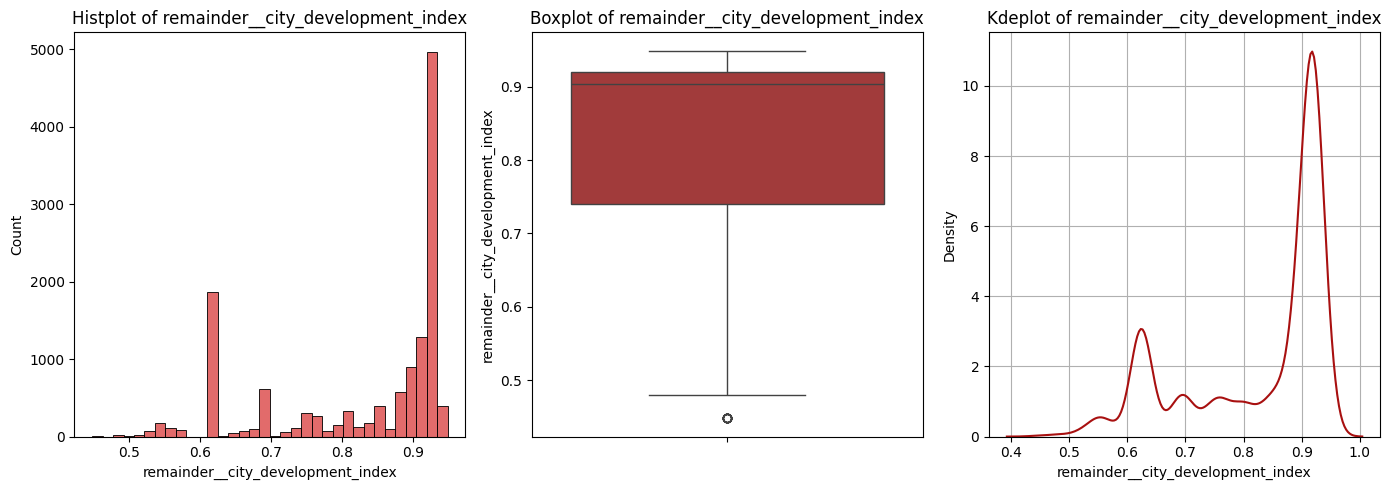

--->remainder__experience<---

The Description of the column : 
count    13410.000000
mean        10.895638
std          7.974015
min          0.500000
25%          4.000000
50%          9.000000
75%         16.000000
max         25.000000
Name: remainder__experience, dtype: float64

The Skewness of the column : 0.67
The Kurtosis of the column : -0.84

===========================================================================IQR=============================================================================================================================
The Lower bound : -14.00
The Upper bound : 34.00
The Number of outlier for this column by IQR : 0
The Percentage of outlier for this column by IQR : 0.0
The Graphical Analysis : 



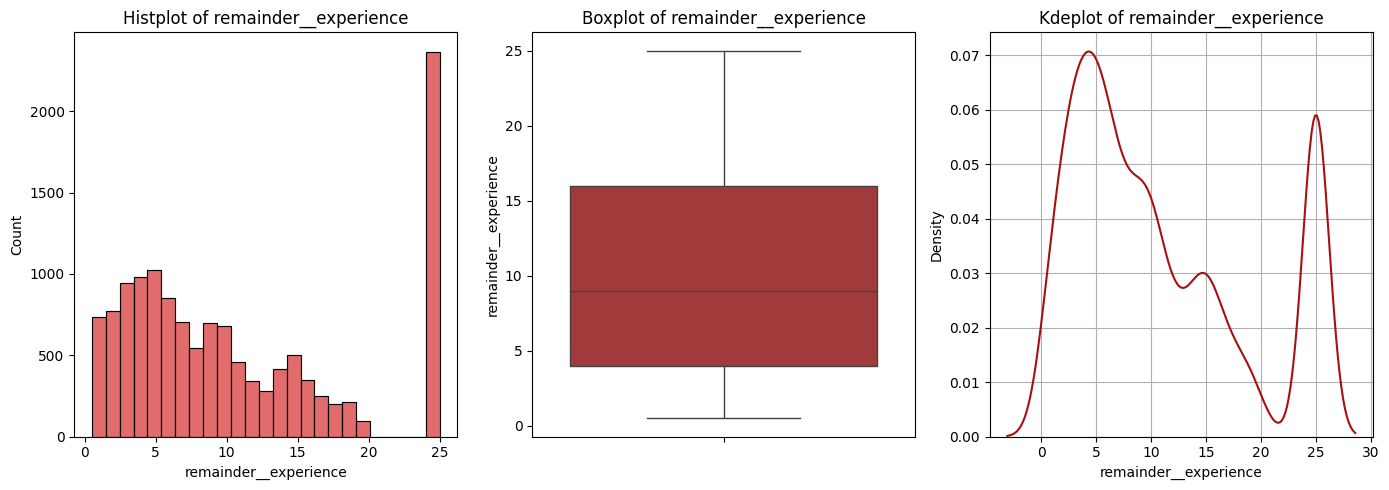

--->remainder__training_hours<---

The Description of the column : 
count    13410.000000
mean        65.299553
std         59.912017
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: remainder__training_hours, dtype: float64

The Skewness of the column : 1.82
The Kurtosis of the column : 3.88

===========================================================================IQR=============================================================================================================================
The Lower bound : -74.50
The Upper bound : 185.50
The Number of outlier for this column by IQR : 680
The Percentage of outlier for this column by IQR : 5.070842654735272
The Graphical Analysis : 



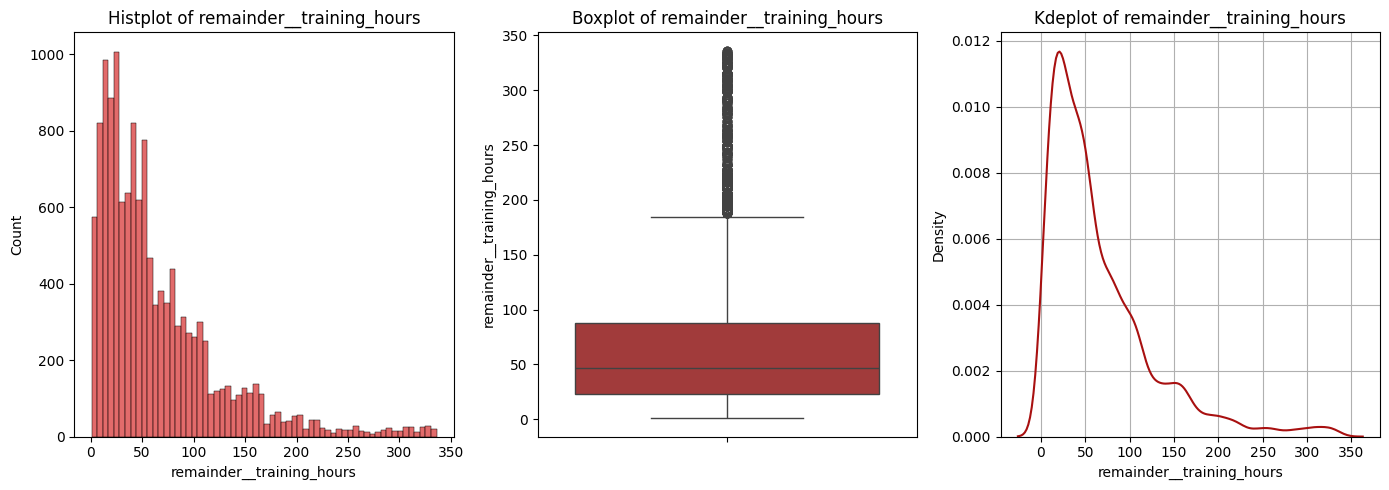

In [92]:
def get_numeric_continous_evaluation(df,numeric_continous_columns):
    for x in numeric_continous_columns:
        print(f'--->{x}<---\n')
        print(f'The Description of the column : \n{df[x].describe()}\n')
        print(f'The Skewness of the column : {df[x].skew():.2f}')
        print(f'The Kurtosis of the column : {df[x].kurt():.2f}\n')

        data = df[x]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5*IQR)
        upper_bound = Q3 + (1.5*IQR)
        no_of_outlier = ((df[x] > upper_bound ) | (df[x] < lower_bound )).sum()
        percentage_outlier = no_of_outlier/len(df)*100

        print(f'{'='*75}IQR{'='*125}')
        print(f'The Lower bound : {lower_bound:.2f}')
        print(f'The Upper bound : {upper_bound:.2f}')
        print(f'The Number of outlier for this column by IQR : {no_of_outlier}')
        print(f'The Percentage of outlier for this column by IQR : {percentage_outlier}')
        print(f'='*250)

        print(f'The Graphical Analysis : \n')

        figure , axes = plt.subplots(1,3,figsize=(14,5))

        sns.histplot(
                        data = df,
                        x = x,
                        ax = axes[0],
                        color = "#D93A3A"
        )
        axes[0].set_title(f'Histplot of {x}')

        sns.boxplot(
                        data = df,
                        y = x,
                        ax = axes[1],
                        color = "#B22A2A"
        )
        axes[1].set_title(f'Boxplot of {x}')

        sns.kdeplot(
                        data = df,
                        x = x,
                        ax = axes[2],
                        color = "#A81010"
        )
        axes[2].set_title(f'Kdeplot of {x}')

        plt.tight_layout()
        plt.grid()
        plt.show()

get_numeric_continous_evaluation(df=X_train,numeric_continous_columns=numeric_continous_columns)

In [93]:
# Need to decide strategies and analysis here

In [94]:
# At this point we have decided to use RobustScaler only for the columns : 'remainder__experience' , 'remainder__training_hours' 
# Cause we are gonna model experemnting here afterwards and then at the end get results and compare to see whether transformation is required for our skewed data 

In [95]:
# We are using RobustScaler
scaler = RobustScaler()

In [96]:
X_train[['remainder__experience' , 'remainder__training_hours' ]] = scaler.fit_transform(X_train[['remainder__experience' , 'remainder__training_hours' ]])
X_test[['remainder__experience' , 'remainder__training_hours' ]] = scaler.transform(X_test[['remainder__experience' , 'remainder__training_hours' ]])

In [97]:
# Model Training

In [98]:
# first let me make imbalanced ratio to make sure we have one for when we are using tree models

In [99]:
imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

In [100]:
# Model we are gonna use first :
#                                   XGBClassifier , LGBMClassifier , CatBoostClassifier      
# 
# Fallback models : 
#                                   RandomForestClassifier , LogisticRegression 
# 
# Ensembleing Techniques :  
#                                       VotingClassifier                                                                                  #

In [101]:
# XGBClassifier model training
xgbc = XGBClassifier(scale_pos_weight=imbalance_ratio)
xgbc.fit(X_train,y_train)
y_pred_xgbc = xgbc.predict(X_test)

The classification_report : 
              precision    recall  f1-score   support

         0.0       0.88      0.80      0.84      4300
         1.0       0.54      0.68      0.60      1448

    accuracy                           0.77      5748
   macro avg       0.71      0.74      0.72      5748
weighted avg       0.79      0.77      0.78      5748


The Roc Auc score : 0.7409347295387383
The cohen_kappa_score : 0.4419864695494151

The confusion_matrix : 
[[3444  856]
 [ 462  986]]

Visualizing the confusion martrix and roc-auc-cruve : 



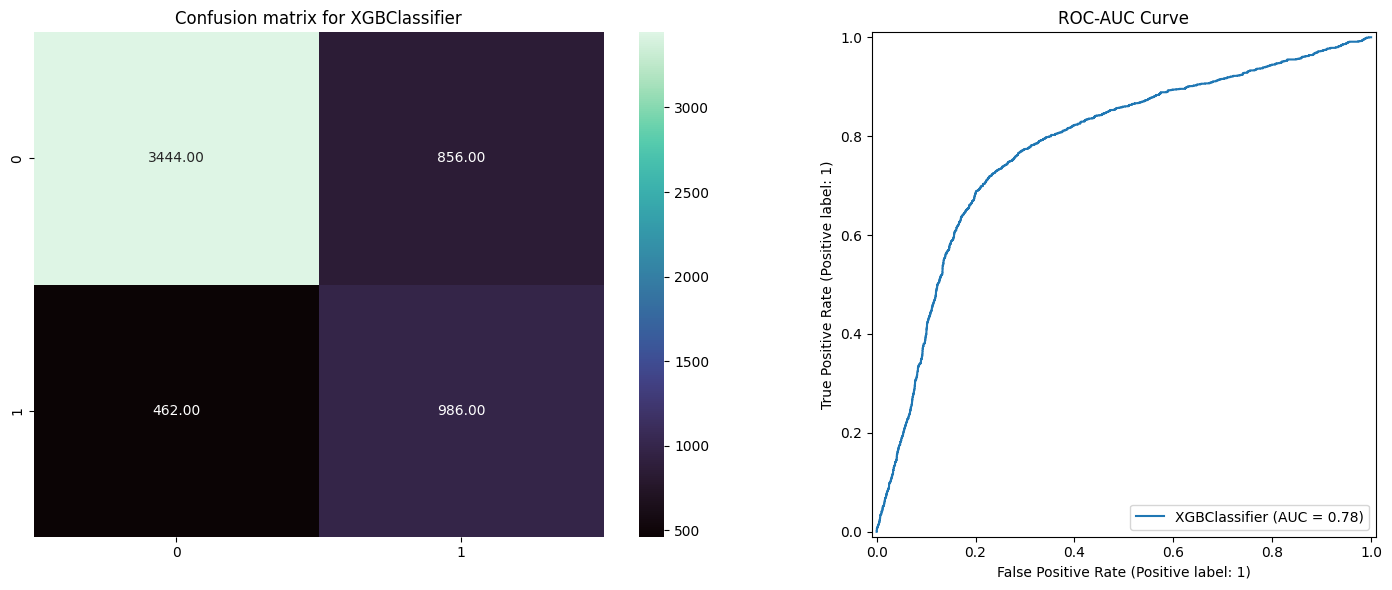

In [108]:
# XGBClassifier model evaluation
print(f'The classification_report : \n{classification_report(y_test,y_pred_xgbc)}\n')
print(f'The Roc Auc score : {roc_auc_score(y_test,y_pred_xgbc)}')
print(f'The cohen_kappa_score : {cohen_kappa_score(y_test,y_pred_xgbc)}\n')
print(f'The confusion_matrix : \n{confusion_matrix(y_test,y_pred_xgbc)}\n')

print(f'Visualizing the confusion martrix and roc-auc-cruve : \n')
# 1. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot Confusion Matrix on the first subplot (axes[0])
axes[0].set_title('Confusion matrix for XGBClassifier')
sns.heatmap(
    data=confusion_matrix(y_test, y_pred_xgbc),
    annot=True,
    cmap="mako",
    fmt='.2f',
    ax=axes[0]  # Directs the heatmap to the first subplot
)

# 3. Plot ROC-AUC Curve on the second subplot (axes[1])
# Note: Use ax=axes[1] to place it next to the heatmap
RocCurveDisplay.from_estimator(
    xgbc, X_test, y_test, 
    name='XGBClassifier', 
    ax=axes[1]  # Directs the ROC curve to the second subplot
)
axes[1].set_title('ROC-AUC Curve')

# 4. Final adjustments
plt.tight_layout()
plt.show()



In [103]:
# Catboost model training
catb = CatBoostClassifier(auto_class_weights='Balanced',verbose=False)
catb.fit(X_train,y_train)
y_pred_catb = catb.predict(X_test)

The classification_report : 
              precision    recall  f1-score   support

         0.0       0.89      0.80      0.85      4300
         1.0       0.55      0.72      0.62      1448

    accuracy                           0.78      5748
   macro avg       0.72      0.76      0.73      5748
weighted avg       0.81      0.78      0.79      5748


The Roc Auc score : 0.7606276500064244
The cohen_kappa_score : 0.4736351306269586

The confusion_matrix : 
[[3453  847]
 [ 408 1040]]

Visualizing the confusion martrix and roc-auc-cruve : 



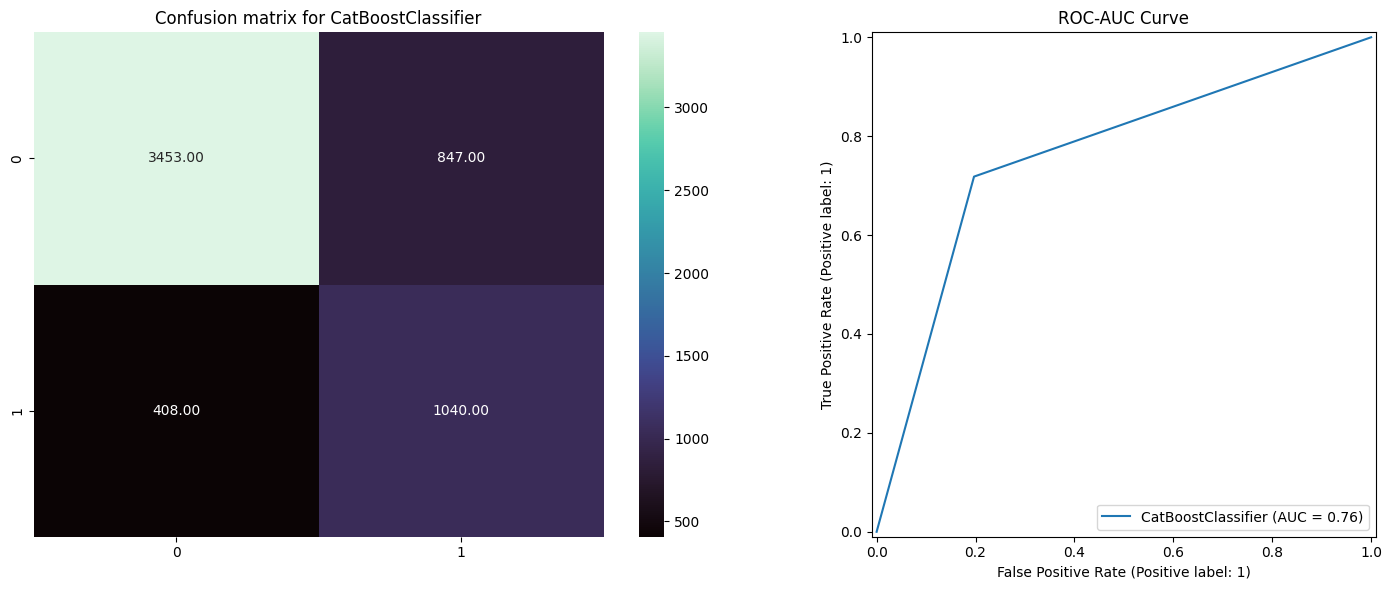

In [111]:
# CatBoostClassifier model evaluation
print(f'The classification_report : \n{classification_report(y_test,y_pred_catb)}\n')
print(f'The Roc Auc score : {roc_auc_score(y_test,y_pred_catb)}')
print(f'The cohen_kappa_score : {cohen_kappa_score(y_test,y_pred_catb)}\n')
print(f'The confusion_matrix : \n{confusion_matrix(y_test,y_pred_catb)}\n')

print(f'Visualizing the confusion martrix and roc-auc-cruve : \n')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].set_title('Confusion matrix for CatBoostClassifier')
sns.heatmap(
    data=confusion_matrix(y_test, y_pred_catb),
    annot=True,
    cmap="mako",
    fmt='.2f',
    ax=axes[0]  
)

RocCurveDisplay.from_predictions(
    y_test, 
    y_pred_catb,
    name='CatBoostClassifier', 
    ax=axes[1] 
)
axes[1].set_title('ROC-AUC Curve')

plt.tight_layout()
plt.show()



In [105]:
# LGBMClassifier model training 
lgbm = LGBMClassifier(class_weight='balanced')
lgbm.fit(X_train,y_train)
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3329, number of negative: 10081
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004774 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 412
[LightGBM] [Info] Number of data points in the train set: 13410, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


The classification_report : 
              precision    recall  f1-score   support

         0.0       0.89      0.80      0.85      4300
         1.0       0.55      0.72      0.62      1448

    accuracy                           0.78      5748
   macro avg       0.72      0.76      0.73      5748
weighted avg       0.81      0.78      0.79      5748


The Roc Auc score : 0.7599299755878197
The cohen_kappa_score : 0.47177818879837696

The confusion_matrix : 
[[3447  853]
 [ 408 1040]]

Visualizing the confusion martrix and roc-auc-cruve : 



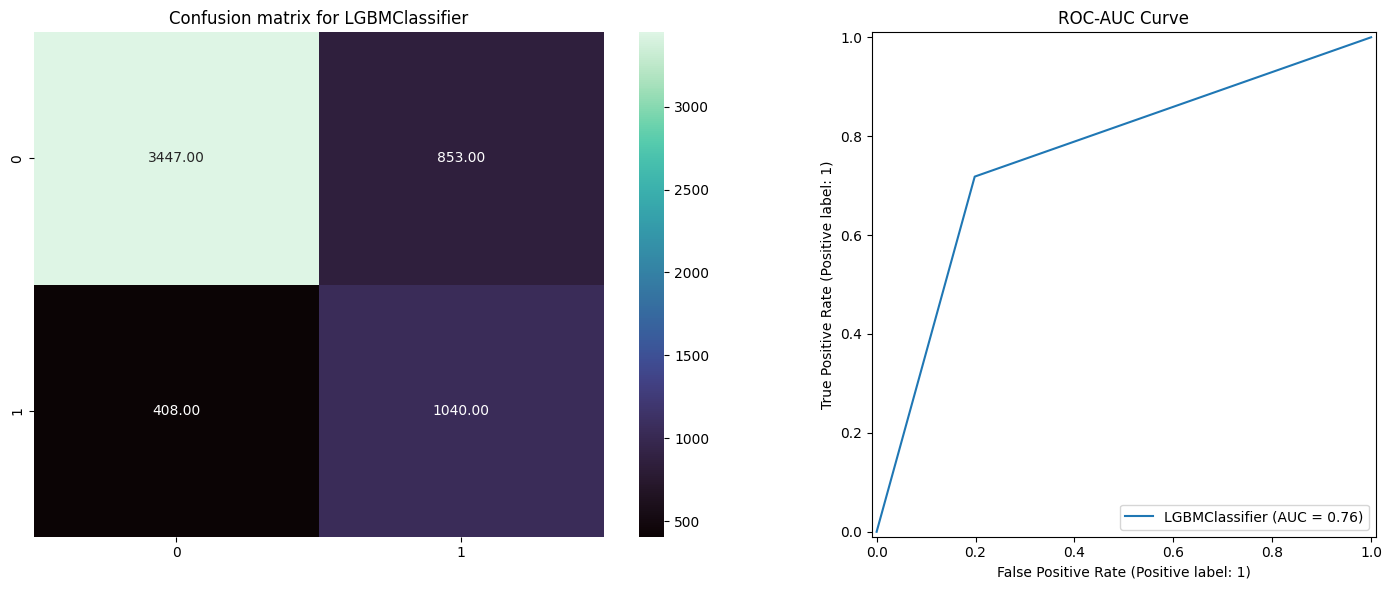

In [110]:
# LGBMClassifier model evaluation

print(f'The classification_report : \n{classification_report(y_test,y_pred_lgbm)}\n')
print(f'The Roc Auc score : {roc_auc_score(y_test,y_pred_lgbm)}')
print(f'The cohen_kappa_score : {cohen_kappa_score(y_test,y_pred_lgbm)}\n')
print(f'The confusion_matrix : \n{confusion_matrix(y_test,y_pred_lgbm)}\n')

print(f'Visualizing the confusion martrix and roc-auc-cruve : \n')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].set_title('Confusion matrix for LGBMClassifier')
sns.heatmap(
    data=confusion_matrix(y_test, y_pred_lgbm),
    annot=True,
    cmap="mako",
    fmt='.2f',
    ax=axes[0]  
)

RocCurveDisplay.from_predictions(
    y_test, 
    y_pred_lgbm,
    name='LGBMClassifier', 
    ax=axes[1] 
)
axes[1].set_title('ROC-AUC Curve')

plt.tight_layout()
plt.show()



In [115]:
# Hyper parameter Tuning catboost as it has the best result

In [118]:
base_model = CatBoostClassifier(
                                    auto_class_weights = 'Balanced',
                                    random_state = 42,
                                    verbose = 1
)

In [ ]:
param_map_catb = {
                        'iterations': [100,250,500,750,1000],
                        'depth': [4,6,8,10],
                        'learning_rate': [0.001,0.05,0.1,0.2],
                        'l2_leaf_reg': [1, 3, 5, 7, 9   ]
 }

In [143]:
random_search_result = base_model.randomized_search(
                                        param_distributions = param_map_catb,
                                        X=X_train, 
                                        y=y_train, 
                                        n_iter = 20,
                                        cv = 5,
                                        plot=False
)

0:	learn: 0.6630374	test: 0.6634307	best: 0.6634307 (0)	total: 73.7ms	remaining: 7.29s
1:	learn: 0.6410096	test: 0.6420908	best: 0.6420908 (1)	total: 118ms	remaining: 5.79s
2:	learn: 0.6221704	test: 0.6235161	best: 0.6235161 (2)	total: 143ms	remaining: 4.62s
3:	learn: 0.6082015	test: 0.6096482	best: 0.6096482 (3)	total: 208ms	remaining: 4.99s
4:	learn: 0.5972518	test: 0.5987077	best: 0.5987077 (4)	total: 234ms	remaining: 4.45s
5:	learn: 0.5875383	test: 0.5894627	best: 0.5894627 (5)	total: 297ms	remaining: 4.64s
6:	learn: 0.5791363	test: 0.5812958	best: 0.5812958 (6)	total: 307ms	remaining: 4.08s
7:	learn: 0.5717326	test: 0.5744775	best: 0.5744775 (7)	total: 348ms	remaining: 4s
8:	learn: 0.5667773	test: 0.5695433	best: 0.5695433 (8)	total: 386ms	remaining: 3.9s
9:	learn: 0.5624288	test: 0.5657830	best: 0.5657830 (9)	total: 481ms	remaining: 4.33s
10:	learn: 0.5589923	test: 0.5627866	best: 0.5627866 (10)	total: 530ms	remaining: 4.29s
11:	learn: 0.5557354	test: 0.5601945	best: 0.5601945 (1

In [144]:
random_search_result['params']

{'depth': 10, 'learning_rate': 0.05, 'l2_leaf_reg': 9, 'iterations': 100}

In [145]:
pd.DataFrame(random_search_result['cv_results'])

,iterations,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std
0,0,0.678044,0.000541,0.677282,0.000352
1,1,0.663822,0.000607,0.661790,0.000672
2,2,0.651620,0.000776,0.648701,0.000767
3,3,0.640673,0.000995,0.637421,0.000886
4,4,0.630211,0.001426,0.626236,0.000886
...,...,...,...,...,...
95,95,0.528909,0.009153,0.454180,0.002863
96,96,0.528848,0.009158,0.453548,0.002944
97,97,0.528814,0.009061,0.452991,0.003018
98,98,0.528929,0.009008,0.452392,0.002908


In [ ]:
#end_to_end_churn_pipeline_eda_preprocessing_and_tuning